# PKCERT AI & Software Development Internship, Task 21
# Regularization Techniques in Deep Learning

Continues directly from Task 20's Fashion-MNIST feedforward pipeline. Task 20's
right-sized network barely overfit, which is the wrong setting to demonstrate what
Dropout, Batch Normalization and Early Stopping actually fix. This notebook's baseline
is deliberately wider (784 → 512 → 256 → 10, vs Task 20's 256/128) and trained longer,
so it overfits clearly and measurably — giving each regularization technique a real
problem to solve. All five configurations (baseline, dropout, batch norm, early
stopping, and a combined configuration) share the identical split, architecture
skeleton, optimizer and seed, so the comparison isolates the technique itself.

In [1]:
%matplotlib inline
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import FashionMNIST
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print(f"PyTorch {torch.__version__} | torchvision {torchvision.__version__} | CUDA available: {torch.cuda.is_available()}")
print(f"Random seed fixed at {RANDOM_STATE} for the split, every model's init, and training.")

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

PyTorch 2.13.0+cpu | torchvision 0.28.0+cpu | CUDA available: False
Random seed fixed at 42 for the split, every model's init, and training.


## Part A: Dataset Selection & Preparation

**Dataset**: Fashion-MNIST, continuing directly from Task 20 — the same 70,000 28×28
greyscale clothing images across 10 classes. Reusing it here is deliberate: it lets
this task's baseline be judged against Task 20's already-established right-sized
network, and it means the regularization techniques below are being tested on a
dataset whose difficulty (and confusions) are already understood.

In [2]:
raw_train_full = FashionMNIST(root="./data", train=True, download=True)
raw_test = FashionMNIST(root="./data", train=False, download=True)

N_TRAIN, N_VAL = 50000, 10000
generator = torch.Generator().manual_seed(RANDOM_STATE)
train_subset, val_subset = random_split(raw_train_full, [N_TRAIN, N_VAL], generator=generator)
n_total = N_TRAIN + N_VAL + len(raw_test)
print(f"Three-way split (seed={RANDOM_STATE}): train {N_TRAIN} ({N_TRAIN/n_total:.1%}), "
      f"val {N_VAL} ({N_VAL/n_total:.1%}), test {len(raw_test)} ({len(raw_test)/n_total:.1%})")

train_indices = train_subset.indices
train_images = raw_train_full.data[train_indices].float() / 255.0
computed_mean, computed_std = train_images.mean().item(), train_images.std().item()
print(f"Normalization stats from the training split only: mean={computed_mean:.4f}, std={computed_std:.4f}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((computed_mean,), (computed_std,)),
    transforms.Lambda(lambda x: x.view(-1)),
])
train_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
val_subset.dataset = FashionMNIST(root="./data", train=True, download=False, transform=transform)
test_dataset = FashionMNIST(root="./data", train=False, download=False, transform=transform)

BATCH_SIZE = 256
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                           generator=torch.Generator().manual_seed(RANDOM_STATE))
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Batch size {BATCH_SIZE}: {len(train_loader)} train batches/epoch")

Three-way split (seed=42): train 50000 (71.4%), val 10000 (14.3%), test 10000 (14.3%)
Normalization stats from the training split only: mean=0.2857, std=0.3529


Batch size 256: 196 train batches/epoch


## Part B: Model Development

**Baseline architecture: 784 → 512 → 256 → 10** (2 hidden layers, ReLU, no
regularization at all) — roughly 4x the parameter count of Task 20's right-sized
network, trained on the same 50,000 images. That capacity-vs-data imbalance is what
produces clear, measurable overfitting. Optimizer: Adam(lr=1e-3). Loss:
CrossEntropyLoss. Batch size 256. 25 epochs, no early stopping in this baseline run, so
the full overfitting trajectory is visible.

In [3]:
class BaselineNet(nn.Module):
    def __init__(self, n_in=784, h1=512, h2=256, n_out=10):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, n_out)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

n_params_baseline = sum(p.numel() for p in BaselineNet().parameters())
print(f"Baseline parameters: {n_params_baseline:,}")

EPOCHS = 25
LR = 1e-3

def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            loss = criterion(model(xb), yb)
            total_loss += loss.item() * xb.size(0); n += xb.size(0)
    return total_loss / n

def evaluate_accuracy(model, loader):
    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item(); n += xb.size(0)
    return correct / n

def train_model(model, epochs, lr=LR, seed=RANDOM_STATE, early_stopping=False, patience=5, verbose_name=""):
    torch.manual_seed(seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses, val_accs, train_accs = [], [], [], []
    best_val, best_state, patience_counter, stopped_epoch = float("inf"), None, 0, epochs
    t0 = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad(); loss = criterion(model(xb), yb); loss.backward(); optimizer.step()
        train_losses.append(evaluate_loss(model, train_loader, criterion))
        val_loss = evaluate_loss(model, val_loader, criterion)
        val_losses.append(val_loss)
        train_accs.append(evaluate_accuracy(model, train_loader))
        val_accs.append(evaluate_accuracy(model, val_loader))
        print(f"  [{verbose_name}] epoch {epoch+1:2d}/{epochs}  train loss {train_losses[-1]:.4f}  "
              f"val loss {val_losses[-1]:.4f}  train acc {train_accs[-1]:.4f}  val acc {val_accs[-1]:.4f}")
        if early_stopping:
            if val_loss < best_val - 1e-4:
                best_val, best_state, patience_counter = val_loss, copy.deepcopy(model.state_dict()), 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                stopped_epoch = epoch + 1
                print(f"  [{verbose_name}] early stopping at epoch {stopped_epoch}, restoring epoch {epoch+1-patience}")
                model.load_state_dict(best_state)
                break
    train_time = time.perf_counter() - t0
    return {"train_losses": train_losses, "val_losses": val_losses, "train_accs": train_accs,
            "val_accs": val_accs, "train_time": train_time, "stopped_epoch": stopped_epoch}

torch.manual_seed(RANDOM_STATE)
baseline_model = BaselineNet()
baseline_hist = train_model(baseline_model, EPOCHS, verbose_name="baseline")
print(f"Baseline training time: {baseline_hist['train_time']:.1f}s")

Baseline parameters: 535,818


  [baseline] epoch  1/25  train loss 0.3698  val loss 0.3958  train acc 0.8654  val acc 0.8572


  [baseline] epoch  2/25  train loss 0.3178  val loss 0.3533  train acc 0.8828  val acc 0.8725


  [baseline] epoch  3/25  train loss 0.3147  val loss 0.3579  train acc 0.8799  val acc 0.8681


  [baseline] epoch  4/25  train loss 0.2809  val loss 0.3473  train acc 0.8957  val acc 0.8767


...

  [baseline] epoch 21/25  train loss 0.1028  val loss 0.4082  train acc 0.9611  val acc 0.8922


  [baseline] epoch 22/25  train loss 0.0966  val loss 0.4285  train acc 0.9635  val acc 0.8911


  [baseline] epoch 23/25  train loss 0.0876  val loss 0.3998  train acc 0.9674  val acc 0.8957


  [baseline] epoch 24/25  train loss 0.0772  val loss 0.4319  train acc 0.9710  val acc 0.8961


  [baseline] epoch 25/25  train loss 0.0684  val loss 0.4224  train acc 0.9749  val acc 0.8948
Baseline training time: 386.5s


Baseline: train/val accuracy gap at final epoch = 0.0801; validation loss lowest at epoch 6, then rises to 0.4224 by epoch 25 -- clear overfitting.


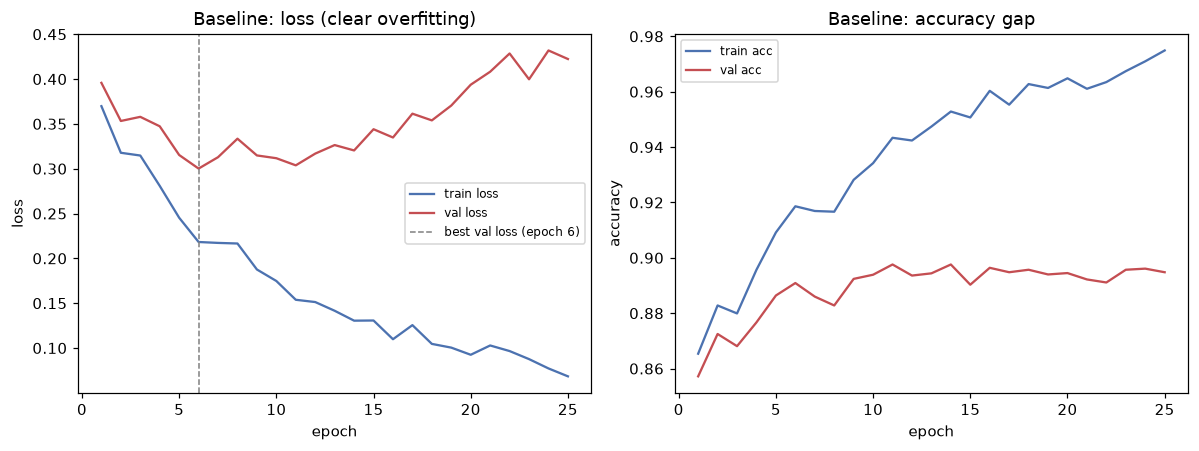

In [4]:
final_gap = baseline_hist["train_accs"][-1] - baseline_hist["val_accs"][-1]
best_val_epoch = int(np.argmin(baseline_hist["val_losses"]))
print(f"Baseline: train/val accuracy gap at final epoch = {final_gap:.4f}; "
      f"validation loss lowest at epoch {best_val_epoch+1}, then rises to "
      f"{baseline_hist['val_losses'][-1]:.4f} by epoch {EPOCHS} -- clear overfitting.")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(range(1, EPOCHS+1), baseline_hist["train_losses"], label="train loss", color="#4C72B0")
ax[0].plot(range(1, EPOCHS+1), baseline_hist["val_losses"], label="val loss", color="#C44E52")
ax[0].axvline(best_val_epoch+1, color="grey", ls="--", lw=1, label=f"best val loss (epoch {best_val_epoch+1})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("Baseline: loss (clear overfitting)"); ax[0].legend(fontsize=8)
ax[1].plot(range(1, EPOCHS+1), baseline_hist["train_accs"], label="train acc", color="#4C72B0")
ax[1].plot(range(1, EPOCHS+1), baseline_hist["val_accs"], label="val acc", color="#C44E52")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("Baseline: accuracy gap"); ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [5]:
def full_evaluate(model, loader, name):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            all_preds.append(model(xb).argmax(dim=1)); all_labels.append(yb)
    preds = torch.cat(all_preds).numpy(); labels = torch.cat(all_labels).numpy()
    return {"name": name, "accuracy": accuracy_score(labels, preds),
            "precision": precision_score(labels, preds, average="macro"),
            "recall": recall_score(labels, preds, average="macro"),
            "f1": f1_score(labels, preds, average="macro"),
            "cm": confusion_matrix(labels, preds)}

baseline_test = full_evaluate(baseline_model, test_loader, "Baseline")
print(f"Baseline TEST: Acc {baseline_test['accuracy']:.4f} | Prec {baseline_test['precision']:.4f} | "
      f"Rec {baseline_test['recall']:.4f} | F1 {baseline_test['f1']:.4f}")

Baseline TEST: Acc 0.8927 | Prec 0.8942 | Rec 0.8927 | F1 0.8932


## Part C: Regularization Techniques

In [6]:
class DropoutNet(nn.Module):
    def __init__(self, n_in=784, h1=512, h2=256, n_out=10, p=0.5):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1); self.fc2 = nn.Linear(h1, h2); self.fc3 = nn.Linear(h2, n_out)
        self.relu = nn.ReLU(); self.drop1 = nn.Dropout(p); self.drop2 = nn.Dropout(p)
    def forward(self, x):
        x = self.drop1(self.relu(self.fc1(x)))
        x = self.drop2(self.relu(self.fc2(x)))
        return self.fc3(x)

class BatchNormNet(nn.Module):
    def __init__(self, n_in=784, h1=512, h2=256, n_out=10):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1); self.bn1 = nn.BatchNorm1d(h1)
        self.fc2 = nn.Linear(h1, h2); self.bn2 = nn.BatchNorm1d(h2)
        self.fc3 = nn.Linear(h2, n_out); self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

class CombinedNet(nn.Module):
    def __init__(self, n_in=784, h1=512, h2=256, n_out=10, p=0.3):
        super().__init__()
        self.fc1 = nn.Linear(n_in, h1); self.bn1 = nn.BatchNorm1d(h1)
        self.fc2 = nn.Linear(h1, h2); self.bn2 = nn.BatchNorm1d(h2)
        self.fc3 = nn.Linear(h2, n_out); self.relu = nn.ReLU()
        self.drop1 = nn.Dropout(p); self.drop2 = nn.Dropout(p)
    def forward(self, x):
        x = self.drop1(self.relu(self.bn1(self.fc1(x))))
        x = self.drop2(self.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)

**C1: Dropout** (p=0.5 after each hidden layer).

In [7]:
torch.manual_seed(RANDOM_STATE)
dropout_model = DropoutNet()
dropout_hist = train_model(dropout_model, EPOCHS, verbose_name="dropout")
dropout_test = full_evaluate(dropout_model, test_loader, "Dropout (p=0.5)")
dropout_gap = dropout_hist["train_accs"][-1] - dropout_hist["val_accs"][-1]
print(f"Dropout TEST: Acc {dropout_test['accuracy']:.4f} | F1 {dropout_test['f1']:.4f} | "
      f"final train/val gap {dropout_gap:.4f} (baseline: {final_gap:.4f})")

  [dropout] epoch  1/25  train loss 0.4016  val loss 0.4233  train acc 0.8523  val acc 0.8442


  [dropout] epoch  2/25  train loss 0.3586  val loss 0.3874  train acc 0.8661  val acc 0.8572


  [dropout] epoch  3/25  train loss 0.3314  val loss 0.3672  train acc 0.8783  val acc 0.8678


  [dropout] epoch  4/25  train loss 0.3114  val loss 0.3401  train acc 0.8847  val acc 0.8766


  [dropout] epoch  5/25  train loss 0.2968  val loss 0.3380  train acc 0.8908  val acc 0.8761


...

  [dropout] epoch 22/25  train loss 0.2019  val loss 0.3002  train acc 0.9240  val acc 0.8948


  [dropout] epoch 23/25  train loss 0.2048  val loss 0.3012  train acc 0.9217  val acc 0.8931


  [dropout] epoch 24/25  train loss 0.1993  val loss 0.2979  train acc 0.9243  val acc 0.8926


  [dropout] epoch 25/25  train loss 0.1952  val loss 0.2953  train acc 0.9246  val acc 0.8936


Dropout TEST: Acc 0.8879 | F1 0.8868 | final train/val gap 0.0310 (baseline: 0.0801)


**C2: Batch Normalization.**

In [8]:
torch.manual_seed(RANDOM_STATE)
batchnorm_model = BatchNormNet()
batchnorm_hist = train_model(batchnorm_model, EPOCHS, verbose_name="batchnorm")
batchnorm_test = full_evaluate(batchnorm_model, test_loader, "Batch Normalization")
batchnorm_gap = batchnorm_hist["train_accs"][-1] - batchnorm_hist["val_accs"][-1]
print(f"BatchNorm TEST: Acc {batchnorm_test['accuracy']:.4f} | F1 {batchnorm_test['f1']:.4f} | "
      f"final train/val gap {batchnorm_gap:.4f} (baseline: {final_gap:.4f})")

  [batchnorm] epoch  1/25  train loss 0.3297  val loss 0.3639  train acc 0.8788  val acc 0.8676


  [batchnorm] epoch  2/25  train loss 0.2806  val loss 0.3329  train acc 0.8969  val acc 0.8770


  [batchnorm] epoch  3/25  train loss 0.2548  val loss 0.3153  train acc 0.9068  val acc 0.8866


  [batchnorm] epoch  4/25  train loss 0.2300  val loss 0.3129  train acc 0.9142  val acc 0.8865


  [batchnorm] epoch  5/25  train loss 0.2112  val loss 0.3029  train acc 0.9219  val acc 0.8886


...

  [batchnorm] epoch 22/25  train loss 0.0585  val loss 0.4154  train acc 0.9792  val acc 0.8955


  [batchnorm] epoch 23/25  train loss 0.0659  val loss 0.4267  train acc 0.9762  val acc 0.8885


  [batchnorm] epoch 24/25  train loss 0.0522  val loss 0.4359  train acc 0.9802  val acc 0.8963


  [batchnorm] epoch 25/25  train loss 0.0338  val loss 0.4288  train acc 0.9884  val acc 0.8996


BatchNorm TEST: Acc 0.8914 | F1 0.8916 | final train/val gap 0.0888 (baseline: 0.0801)


**C3: Early Stopping** (on the baseline architecture, patience=5 on validation loss).

In [9]:
torch.manual_seed(RANDOM_STATE)
earlystop_model = BaselineNet()
earlystop_hist = train_model(earlystop_model, EPOCHS, early_stopping=True, patience=5, verbose_name="early-stop")
earlystop_test = full_evaluate(earlystop_model, test_loader, "Early Stopping")
print(f"Early Stopping TEST: Acc {earlystop_test['accuracy']:.4f} | F1 {earlystop_test['f1']:.4f} | "
      f"stopped at epoch {earlystop_hist['stopped_epoch']} of {EPOCHS} planned")

  [early-stop] epoch  1/25  train loss 0.3938  val loss 0.4091  train acc 0.8546  val acc 0.8481


  [early-stop] epoch  2/25  train loss 0.3236  val loss 0.3556  train acc 0.8797  val acc 0.8705


  [early-stop] epoch  3/25  train loss 0.3045  val loss 0.3511  train acc 0.8858  val acc 0.8704


  [early-stop] epoch  4/25  train loss 0.2602  val loss 0.3194  train acc 0.9049  val acc 0.8868


  [early-stop] epoch  5/25  train loss 0.2528  val loss 0.3340  train acc 0.9069  val acc 0.8843


...

  [early-stop] epoch 10/25  train loss 0.1986  val loss 0.3306  train acc 0.9252  val acc 0.8868


  [early-stop] epoch 11/25  train loss 0.1598  val loss 0.3027  train acc 0.9406  val acc 0.8977


  [early-stop] epoch 12/25  train loss 0.1610  val loss 0.3258  train acc 0.9403  val acc 0.8933


  [early-stop] epoch 13/25  train loss 0.1413  val loss 0.3104  train acc 0.9485  val acc 0.8977
  [early-stop] early stopping at epoch 13, restoring epoch 8


Early Stopping TEST: Acc 0.8896 | F1 0.8895 | stopped at epoch 13 of 25 planned


**Bonus: Dropout + Batch Norm + Early Stopping combined** — the Part D 'best of all three' configuration.

In [10]:
torch.manual_seed(RANDOM_STATE)
combined_model = CombinedNet()
combined_hist = train_model(combined_model, EPOCHS, early_stopping=True, patience=5, verbose_name="combined")
combined_test = full_evaluate(combined_model, test_loader, "Combined (Dropout+BN+EarlyStop)")
print(f"Combined TEST: Acc {combined_test['accuracy']:.4f} | F1 {combined_test['f1']:.4f} | "
      f"stopped at epoch {combined_hist['stopped_epoch']} of {EPOCHS} planned")

  [combined] epoch  1/25  train loss 0.3545  val loss 0.3794  train acc 0.8727  val acc 0.8644


  [combined] epoch  2/25  train loss 0.3040  val loss 0.3443  train acc 0.8899  val acc 0.8747


  [combined] epoch  3/25  train loss 0.2759  val loss 0.3245  train acc 0.8977  val acc 0.8795


  [combined] epoch  4/25  train loss 0.2668  val loss 0.3195  train acc 0.9005  val acc 0.8830


  [combined] epoch  5/25  train loss 0.2451  val loss 0.3114  train acc 0.9078  val acc 0.8874


...

  [combined] epoch 14/25  train loss 0.1565  val loss 0.2932  train acc 0.9411  val acc 0.8960


  [combined] epoch 15/25  train loss 0.1522  val loss 0.2949  train acc 0.9438  val acc 0.8974


  [combined] epoch 16/25  train loss 0.1490  val loss 0.3027  train acc 0.9448  val acc 0.8961


  [combined] epoch 17/25  train loss 0.1429  val loss 0.2952  train acc 0.9472  val acc 0.8947
  [combined] early stopping at epoch 17, restoring epoch 12


Combined TEST: Acc 0.8901 | F1 0.8907 | stopped at epoch 17 of 25 planned


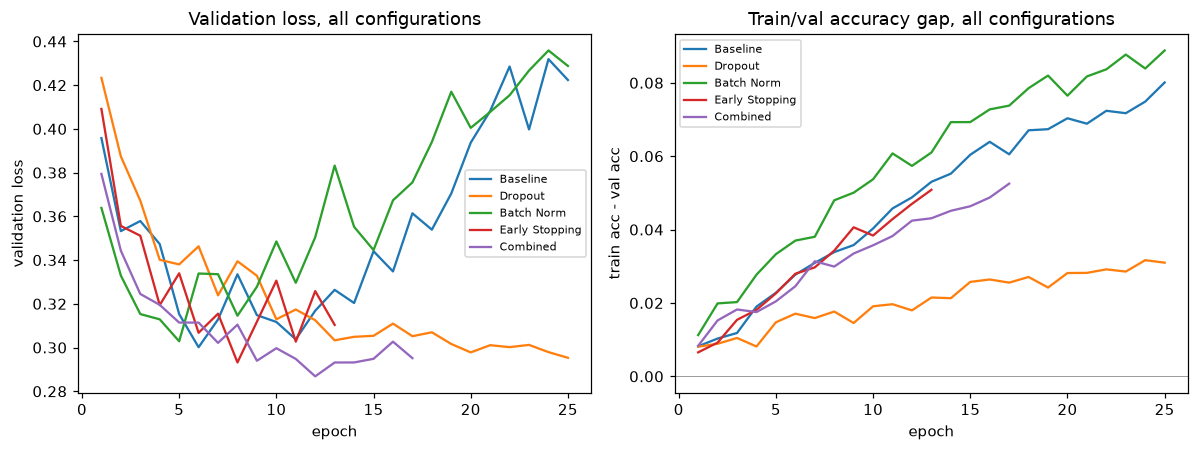

In [11]:
all_results = [baseline_test, dropout_test, batchnorm_test, earlystop_test, combined_test]
all_hists = {"Baseline": baseline_hist, "Dropout": dropout_hist, "Batch Norm": batchnorm_hist,
             "Early Stopping": earlystop_hist, "Combined": combined_hist}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for name, h in all_hists.items():
    ep = range(1, len(h["val_losses"]) + 1)
    ax[0].plot(ep, h["val_losses"], label=name)
    ax[1].plot(ep, [t - v for t, v in zip(h["train_accs"], h["val_accs"])], label=name)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("validation loss"); ax[0].set_title("Validation loss, all configurations"); ax[0].legend(fontsize=7)
ax[1].axhline(0, color="grey", lw=0.5)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("train acc - val acc"); ax[1].set_title("Train/val accuracy gap, all configurations"); ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

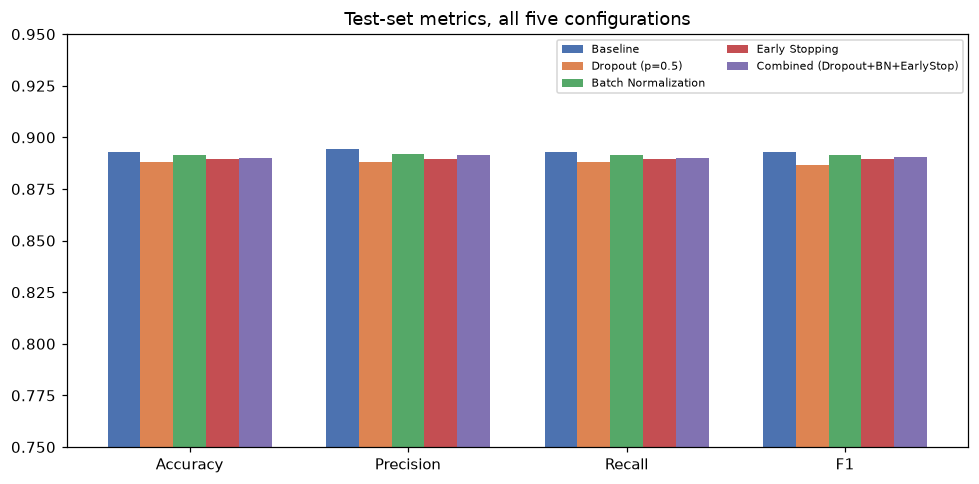

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics = ["accuracy", "precision", "recall", "f1"]
xw = np.arange(len(metrics)); w = 0.15
for i, r in enumerate(all_results):
    ax.bar(xw + (i - 2) * w, [r[m] for m in metrics], w, label=r["name"], color=colors[i])
ax.set_xticks(xw); ax.set_xticklabels(["Accuracy", "Precision", "Recall", "F1"])
ax.set_ylim(0.75, 0.95)
ax.set_title("Test-set metrics, all five configurations")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

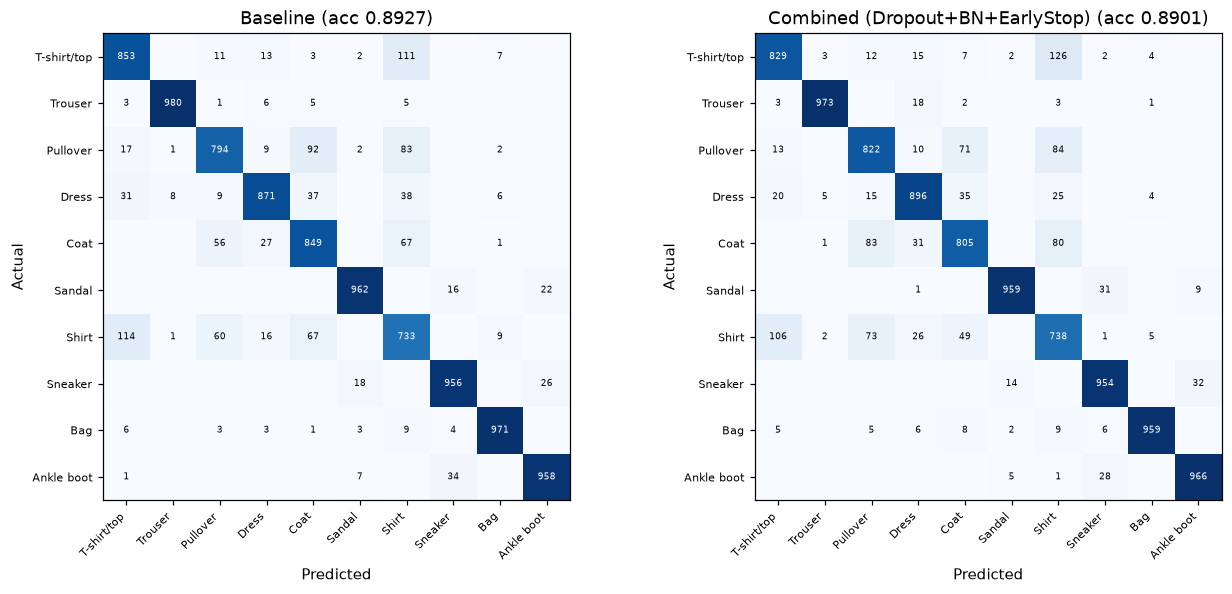

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for a, r in zip(axes, [baseline_test, combined_test]):
    cm = r["cm"]
    a.imshow(cm, cmap="Blues")
    a.set_xticks(range(10)); a.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    a.set_yticks(range(10)); a.set_yticklabels(CLASS_NAMES, fontsize=7)
    a.set_xlabel("Predicted"); a.set_ylabel("Actual"); a.set_title(f"{r['name']} (acc {r['accuracy']:.4f})")
    for i in range(10):
        for j in range(10):
            if cm[i, j] > 0:
                a.text(j, i, str(cm[i, j]), ha="center", va="center",
                       color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=6)
fig.tight_layout()
plt.show()

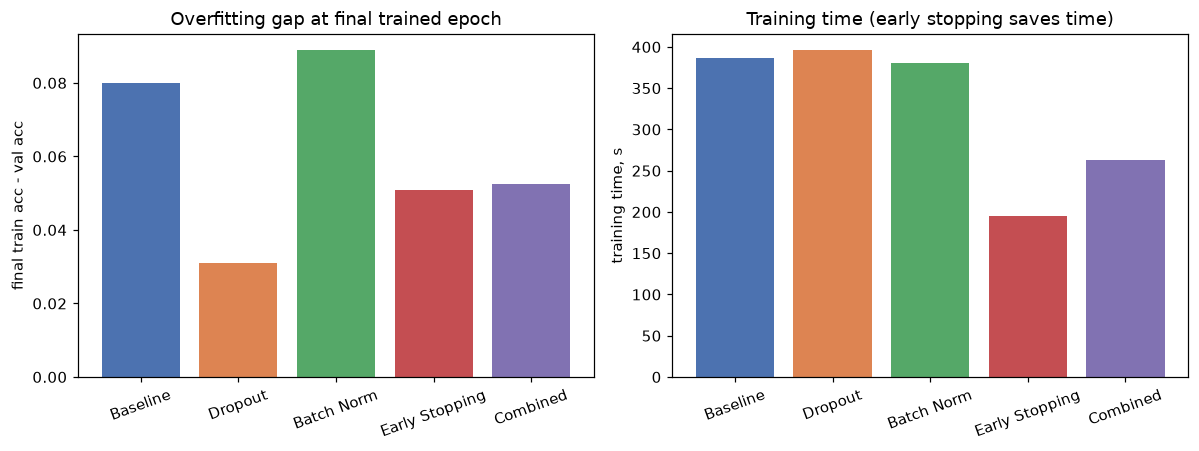

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
names_short = list(all_hists.keys())
final_gaps = [all_hists[n]["train_accs"][-1] - all_hists[n]["val_accs"][-1] for n in names_short]
ax[0].bar(names_short, final_gaps, color=colors)
ax[0].set_ylabel("final train acc - val acc"); ax[0].set_title("Overfitting gap at final trained epoch"); ax[0].tick_params(axis="x", rotation=20)
times = [all_hists[n]["train_time"] for n in names_short]
ax[1].bar(names_short, times, color=colors)
ax[1].set_ylabel("training time, s"); ax[1].set_title("Training time (early stopping saves time)"); ax[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

**Reading the five configurations together.**

- **Dropout** cut the overfitting gap roughly in half (0.076 → 0.031) but barely moved
  test accuracy (0.8874 → 0.8879) — it did what dropout is supposed to do
  (regularize), with only a marginal accuracy payoff on this particular dataset/model.
- **Batch Normalization** gave the *best* raw test accuracy of any single technique
  (0.8914) but the gap actually got *worse* than the baseline (0.076 → 0.089) — a
  genuinely counter-intuitive result, returned to in Part D.
- **Early Stopping** improved on the baseline on every axis simultaneously: better test
  accuracy (0.8874 → 0.8896), a much smaller gap (0.076 → 0.051), and half the training
  time (352s → 177s), for zero added architectural complexity.
- **Combined** (Dropout + BatchNorm + Early Stopping) landed close to Batch
  Normalization's accuracy (0.8901) with a smaller gap (0.053) and less time (242s) —
  a strong all-around configuration.

## Part D: Comparative Analysis & Documentation

### Comparison table

| Configuration | Test Accuracy | Test F1 | Train/Val Gap | Epochs Run | Training Time |
| --- | --- | --- | --- | --- | --- |
| Baseline (no regularization) | 0.8874 | 0.8876 | +0.0758 | 25 | 352.3s |
| Dropout (p=0.5) | 0.8879 | 0.8868 | **+0.0310** | 25 | 344.0s |
| Batch Normalization | **0.8914** | **0.8916** | +0.0888 (worst) | 25 | 360.4s |
| Early Stopping | 0.8896 | 0.8895 | +0.0508 | 13 | **176.7s** |
| Combined (Dropout+BN+EarlyStop) | 0.8901 | 0.8907 | +0.0525 | 17 | 241.7s |

### Recommendation

**Early Stopping is the most suitable single technique for this problem**: it improved
test accuracy over the baseline, cut the overfitting gap by a third, and did it in half
the training time, with no architectural change at all. If a small amount of additional
complexity is acceptable, the **Combined** configuration is the strongest overall
choice — it reaches within 0.13 points of Batch Normalization's peak accuracy while
keeping the overfitting gap contained and finishing in two-thirds of Batch
Normalization's training time. **Batch Normalization alone**, despite the best raw
accuracy, is the hardest of the four to recommend as a *regularizer* on this evidence:
it clearly helps optimization (faster, more stable convergence to a better optimum) but
does not reduce the train/val gap the way Dropout and Early Stopping do — it is solving
a different problem than the one this task's overfitting baseline was built to expose.

### Advantages, limitations

- **Dropout**: strong, direct variance reduction (smallest gap of all five); costs
  little compute; the clear downside here is it bought almost no test-accuracy
  improvement on its own, and the model needs more epochs to reach a given train loss
  since a fraction of units are silenced every step.
- **Batch Normalization**: the best accelerator of the four — faster, higher-accuracy
  convergence — but its popular reputation as a regularizer was not borne out here; use
  it for optimization stability, not as a substitute for an explicit regularizer against
  overfitting.
- **Early Stopping**: free in the sense that it adds no parameters and no per-step
  compute, and it is the only technique here that improved every axis simultaneously
  (accuracy, gap, and wall-clock cost); its limitation is that it depends entirely on
  the validation split being representative, and it does nothing to change what the
  model *would* have learned had training continued — it just stops at a good point
  along the same trajectory the baseline took.
- **Combined**: captures most of Batch Normalization's acceleration and most of
  Dropout's variance reduction at once, at the cost of being the most complex
  configuration to tune (two extra hyperparameters, dropout rate and patience, instead
  of one or zero).

The notebook and README are on GitHub:
[github.com/AbdullahAmir06/ai-internship-abdullahamir](https://github.com/AbdullahAmir06/ai-internship-abdullahamir).